# 05. DMFC Encoding Model

Goal:
- Test which model-derived variables explain DMFC population activity.
- Compare deterministic, task-difficulty, MC-derived, and behavior-related feature groups.
- Evaluate each group using cross-validated population R².

In [51]:
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
INTERIM_DIR = DATA_DIR / "interim"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"

for d in [PROCESSED_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ANALYSIS_PATH = PROCESSED_DIR / "mahler_neural_behavior_window_analysis.csv"
PCA_PATH = PROCESSED_DIR / "mahler_neural_pca_preview.csv"

print("ANALYSIS_PATH exists:", ANALYSIS_PATH.exists())
print("PCA_PATH exists:", PCA_PATH.exists())

ANALYSIS_PATH exists: True
PCA_PATH exists: True


In [52]:
analysis_df = pd.read_csv(ANALYSIS_PATH)
pca_df = pd.read_csv(PCA_PATH)

print("analysis_df shape:", analysis_df.shape)
print("pca_df shape:", pca_df.shape)

display(analysis_df.head())
display(pca_df.head())

analysis_df shape: (316, 117)
pca_df shape: (308, 22)


,condition_i,window,unit_000,unit_001,unit_002,unit_003,unit_004,unit_005,unit_006,unit_007,unit_008,unit_009,unit_010,unit_011,unit_012,unit_013,unit_014,unit_015,unit_016,unit_017,unit_018,unit_019,unit_020,unit_021,unit_022,unit_023,unit_024,unit_025,unit_026,unit_027,unit_028,unit_029,unit_030,unit_031,unit_032,unit_033,unit_034,unit_035,unit_036,unit_037,unit_038,unit_039,unit_040,unit_041,unit_042,unit_043,unit_044,unit_045,unit_046,unit_047,unit_048,unit_049,unit_050,unit_051,unit_052,unit_053,unit_054,unit_055,unit_056,unit_057,unit_058,unit_059,unit_060,unit_061,unit_062,unit_063,unit_064,unit_065,unit_066,unit_067,unit_068,unit_069,unit_070,unit_071,unit_072,unit_073,unit_074,unit_075,unit_076,unit_077,unit_078,unit_079,unit_080,unit_081,unit_082,unit_083,unit_084,unit_085,unit_086,unit_087,unit_088,unit_089,unit_090,unit_091,unit_092,unit_093,unit_094,unit_095,unit_096,unit_097,unit_098,unit_099,y_det,y_true,y_paddle,y_occ,vy_occ,abs_vy_occ,n_steps,n_bounce,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,mc_mean_M6,mc_std_M6,pred_M4_biased_mc_ipe,sigma_M4_biased_mc_ipe,uncertainty_M4_mc
0,0,pre_occ,-0.590960,1.379389,0.452114,0.537548,1.522249,-0.845046,2.053754,3.514321,1.697143,2.149586,1.698270,-1.102545,0.703921,-1.271515,-0.474848,-0.388881,0.780072,-0.779988,-2.119404,-1.273460,-0.998197,1.117492,-0.555672,1.296359,-1.555603,-0.746918,-2.046147,0.234285,-1.294374,-0.088340,-0.510056,0.663737,-2.616444,0.710196,-0.373478,-0.741576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
1,0,early_occ,-1.761323,0.703368,0.012818,0.263659,2.038235,-0.463798,3.206495,1.438544,1.285506,2.240759,1.433952,-2.121635,1.021560,-0.667143,-1.678263,-0.785434,1.103000,-0.775119,-2.028484,-1.319110,-0.473471,0.061597,-0.968218,1.620691,-1.107949,-2.157704,-2.545793,0.926265,-1.978958,0.311227,-0.906618,1.396752,-2.399197,1.016280,0.208842,0.373721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
2,0,late_occ,-2.529047,0.405583,0.375527,0.746150,1.569107,-0.512101,1.947588,1.768042,0.911661,1.733232,-0.286895,-2.597691,0.091238,-0.954154,-2.467268,-1.589378,0.313071,-1.654406,-3.050250,-2.382095,-1.104586,-0.694091,-1.492470,0.149023,-2.130489,-1.784460,-2.654677,0.089028,-1.202022,-0.381539,-1.281830,0.054391,-2.541745,0.237296,-0.538895,-0.089518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
3,0,full_occ,-2.042917,0.574913,0.263535,0.597847,1.957729,-0.368715,2.752251,1.709203,1.200211,2.067702,0.820758,-2.194163,0.802000,-0.663379,-1.848456,-0.955042,0.913092,-1.056834,-2.308680,-1.638676,-0.668167,-0.124003,-1.025869,1.175345,-1.373847,-1.873472,-2.381988,0.716753,-1.594069,0.134549,-1.081084,0.886147,-2.342833,0.531793,0.015582,0.216616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271351,-0.271351,-0.6

,condition_i,window,PC1,PC2,PC3,PC4,PC5,y_det,y_true,y_paddle,y_occ,vy_occ,abs_vy_occ,n_steps,n_bounce,pred_M6_mc_mean_task_uncertainty,sigma_M6_mc_mean_task_uncertainty,mc_mean_M6,mc_std_M6,pred_M4_biased_mc_ipe,sigma_M4_biased_mc_ipe,uncertainty_M4_mc
0,0,pre_occ,1.429697,0.147761,-0.716712,-0.053119,0.679704,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
1,0,early_occ,1.235810,0.132941,-0.335846,0.636141,0.906960,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
2,0,late_occ,0.243098,0.635230,-0.259377,0.859541,0.640063,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
3,0,full_occ,0.989002,0.315490,-0.394452,0.756840,0.760405,-0.271351,-0.271351,-0.688933,-2.787992,0.167776,0.167776,15,1.0,-0.230727,0.718746,-0.069906,0.948261,-0.612109,1.521794,1.463708
4,1,pre_occ,0.600908,0.574002,-2.835429,2.607552,0.632770,-5.085588,-5.085590,-3.723874,-8.066386,0.198720,0.198720,15,0.0,-4.839890,0.630025,-5.188814,0.958497,-4.955276,1.517295,1.426141


In [53]:
unit_cols = [c for c in analysis_df.columns if isinstance(c, str) and c.startswith("unit_")]

print("n unit columns:", len(unit_cols))
print("windows:", analysis_df["window"].unique())
print("conditions:", analysis_df["condition_i"].nunique())

candidate_feature_cols = [
    "y_det",
    "y_true",
    "y_paddle",
    "y_occ",
    "vy_occ",
    "abs_vy_occ",
    "n_steps",
    "n_bounce",
    "pred_M6_mc_mean_task_uncertainty",
    "sigma_M6_mc_mean_task_uncertainty",
    "mc_mean_M6",
    "mc_std_M6",
    "pred_M4_biased_mc_ipe",
    "sigma_M4_biased_mc_ipe",
    "uncertainty_M4_mc",
]

available_features = [c for c in candidate_feature_cols if c in analysis_df.columns]

print("available features:")
for c in available_features:
    print(" -", c)

n unit columns: 100
windows: <StringArray>
['pre_occ', 'early_occ', 'late_occ', 'full_occ']
Length: 4, dtype: str
conditions: 79
available features:
 - y_det
 - y_true
 - y_paddle
 - y_occ
 - vy_occ
 - abs_vy_occ
 - n_steps
 - n_bounce
 - pred_M6_mc_mean_task_uncertainty
 - sigma_M6_mc_mean_task_uncertainty
 - mc_mean_M6
 - mc_std_M6
 - pred_M4_biased_mc_ipe
 - sigma_M4_biased_mc_ipe
 - uncertainty_M4_mc


In [54]:
feature_groups = {
    "G1_y_det": [
        "y_det",
    ],
    
    "G2_deterministic_state": [
        "y_det",
        "y_occ",
        "vy_occ",
        "n_steps",
    ],
    
    "G3_task_difficulty": [
        "abs_vy_occ",
        "n_steps",
        "sigma_M6_mc_mean_task_uncertainty",
    ],
    
    "G4_mc_prediction": [
        "mc_mean_M6",
        "mc_std_M6",
    ],
    
    "G5_behavior": [
        "y_paddle",
    ],
    
    "G6_m6_combined": [
        "mc_mean_M6",
        "abs_vy_occ",
        "n_steps",
    ],
    
    "G7_full_compact": [
        "mc_mean_M6",
        "mc_std_M6",
        "abs_vy_occ",
        "n_steps",
        "y_occ",
        "vy_occ",
    ],
}

# Remove unavailable features
feature_groups = {
    name: [f for f in feats if f in analysis_df.columns]
    for name, feats in feature_groups.items()
}

# Remove empty groups
feature_groups = {
    name: feats
    for name, feats in feature_groups.items()
    if len(feats) > 0
}

feature_groups

{'G1_y_det': ['y_det'],
 'G2_deterministic_state': ['y_det', 'y_occ', 'vy_occ', 'n_steps'],
 'G3_task_difficulty': ['abs_vy_occ',
  'n_steps',
  'sigma_M6_mc_mean_task_uncertainty'],
 'G4_mc_prediction': ['mc_mean_M6', 'mc_std_M6'],
 'G5_behavior': ['y_paddle'],
 'G6_m6_combined': ['mc_mean_M6', 'abs_vy_occ', 'n_steps'],
 'G7_full_compact': ['mc_mean_M6',
  'mc_std_M6',
  'abs_vy_occ',
  'n_steps',
  'y_occ',
  'vy_occ']}

In [55]:
def make_kfold_indices(n, n_splits=5, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, n_splits)
    
    splits = []
    for i in range(n_splits):
        test_idx = folds[i]
        train_idx = np.setdiff1d(idx, test_idx)
        splits.append((train_idx, test_idx))
    
    return splits


def standardize_train_test(X_train, X_test, eps=1e-8):
    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    
    mean = np.nanmean(X_train, axis=0)
    std = np.nanstd(X_train, axis=0)
    std = np.where(std < eps, 1.0, std)
    
    X_train_z = (X_train - mean) / std
    X_test_z = (X_test - mean) / std
    
    # Feature NaN imputation
    X_train_z = np.where(np.isfinite(X_train_z), X_train_z, 0.0)
    X_test_z = np.where(np.isfinite(X_test_z), X_test_z, 0.0)
    
    return X_train_z, X_test_z, mean, std


def fit_ridge(X, Y, alpha=1.0):
    """
    X: n × p
    Y: n × q
    Returns beta: p × q
    """
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    
    I = np.eye(X.shape[1])
    beta = np.linalg.solve(X.T @ X + alpha * I, X.T @ Y)
    return beta


def add_intercept(X):
    X = np.asarray(X, dtype=float)
    return np.column_stack([np.ones(len(X)), X])

In [56]:
def prepare_window_data(df, window, unit_cols, min_unit_finite=0.2):
    sub = df[df["window"] == window].copy().reset_index(drop=True)
    
    Y_raw = sub[unit_cols].to_numpy(dtype=float)
    
    finite_ratio = np.isfinite(Y_raw).mean(axis=0)
    unit_std = np.nanstd(Y_raw, axis=0)
    
    keep_units = (
        (finite_ratio >= min_unit_finite) &
        np.isfinite(unit_std) &
        (unit_std > 1e-8)
    )
    
    if keep_units.sum() < 3:
        # fallback: lower threshold
        keep_units = (
            (finite_ratio >= 0.05) &
            np.isfinite(unit_std) &
            (unit_std > 1e-8)
        )
    
    kept_unit_cols = [c for c, k in zip(unit_cols, keep_units) if k]
    Y = Y_raw[:, keep_units]
    
    return sub, Y, kept_unit_cols


for win in analysis_df["window"].unique():
    sub, Y, kept = prepare_window_data(analysis_df, win, unit_cols)
    print(win, "rows:", len(sub), "units kept:", len(kept), "finite ratio:", np.isfinite(Y).mean())

pre_occ rows: 79 units kept: 32 finite ratio: 0.7685917721518988
early_occ rows: 79 units kept: 32 finite ratio: 0.7464398734177216
late_occ rows: 79 units kept: 33 finite ratio: 0.7529727656309935
full_occ rows: 79 units kept: 33 finite ratio: 0.7702339854238588


c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [57]:
def evaluate_encoding_for_window(
    df,
    window,
    features,
    unit_cols,
    n_splits=5,
    seed=0,
    alpha=1.0,
    min_unit_finite=0.2,
):
    sub, Y_raw, kept_units = prepare_window_data(
        df,
        window,
        unit_cols,
        min_unit_finite=min_unit_finite,
    )
    
    X_raw = sub[features].to_numpy(dtype=float)
    
    # Remove rows with no valid feature values
    valid_x = np.isfinite(X_raw).any(axis=1)
    sub = sub.loc[valid_x].reset_index(drop=True)
    X_raw = X_raw[valid_x]
    Y_raw = Y_raw[valid_x]
    
    splits = make_kfold_indices(len(sub), n_splits=n_splits, seed=seed)
    
    fold_rows = []
    
    all_sse = 0.0
    all_sst = 0.0
    
    for fold, (train_idx, test_idx) in enumerate(splits):
        X_train_raw = X_raw[train_idx]
        X_test_raw = X_raw[test_idx]
        
        Y_train_raw = Y_raw[train_idx]
        Y_test_raw = Y_raw[test_idx]
        
        # Standardize X
        X_train_z, X_test_z, _, _ = standardize_train_test(X_train_raw, X_test_raw)
        X_train_design = add_intercept(X_train_z)
        X_test_design = add_intercept(X_test_z)
        
        # Standardize Y using train statistics
        y_mean = np.nanmean(Y_train_raw, axis=0, keepdims=True)
        y_std = np.nanstd(Y_train_raw, axis=0, keepdims=True)
        y_std = np.where(y_std < 1e-8, 1.0, y_std)
        
        Y_train_z = (Y_train_raw - y_mean) / y_std
        Y_test_z = (Y_test_raw - y_mean) / y_std
        
        # Impute train NaNs with 0 after z-scoring
        Y_train_z_fit = np.where(np.isfinite(Y_train_z), Y_train_z, 0.0)
        
        beta = fit_ridge(X_train_design, Y_train_z_fit, alpha=alpha)
        Y_pred_z = X_test_design @ beta
        
        # Score only originally finite neural values
        mask = np.isfinite(Y_test_z)
        
        if mask.sum() == 0:
            fold_r2 = np.nan
            sse = np.nan
            sst = np.nan
        else:
            residual = Y_test_z[mask] - Y_pred_z[mask]
            sse = np.sum(residual ** 2)
            sst = np.sum(Y_test_z[mask] ** 2)
            fold_r2 = 1.0 - sse / sst if sst > 0 else np.nan
            
            all_sse += sse
            all_sst += sst
        
        fold_rows.append({
            "window": window,
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_features": len(features),
            "n_units": len(kept_units),
            "alpha": alpha,
            "fold_population_r2": fold_r2,
            "sse": sse,
            "sst": sst,
        })
    
    cv_df = pd.DataFrame(fold_rows)
    population_r2 = 1.0 - all_sse / all_sst if all_sst > 0 else np.nan
    
    return cv_df, population_r2

In [58]:
encoding_rows = []
encoding_fold_rows = []

for win in analysis_df["window"].unique():
    for group_name, feats in feature_groups.items():
        cv_df, pop_r2 = evaluate_encoding_for_window(
            df=analysis_df,
            window=win,
            features=feats,
            unit_cols=unit_cols,
            n_splits=5,
            seed=42,
            alpha=1.0,
            min_unit_finite=0.2,
        )
        
        encoding_rows.append({
            "window": win,
            "feature_group": group_name,
            "features": ",".join(feats),
            "population_r2": pop_r2,
            "mean_fold_r2": cv_df["fold_population_r2"].mean(),
            "sem_fold_r2": cv_df["fold_population_r2"].std(ddof=1) / np.sqrt(len(cv_df)),
            "n_features": len(feats),
            "n_units": cv_df["n_units"].iloc[0],
        })
        
        cv_df["feature_group"] = group_name
        cv_df["features"] = ",".join(feats)
        encoding_fold_rows.append(cv_df)

encoding_summary = pd.DataFrame(encoding_rows).sort_values(
    ["window", "population_r2"],
    ascending=[True, False],
)

encoding_folds = pd.concat(encoding_fold_rows, ignore_index=True)

display(encoding_summary)

c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_im

,window,feature_group,features,population_r2,mean_fold_r2,sem_fold_r2,n_features,n_units
11,early_occ,G5_behavior,y_paddle,0.472679,0.472690,0.027952,1,32
12,early_occ,G6_m6_combined,"mc_mean_M6,abs_vy_occ,n_steps",0.444503,0.447217,0.035933,3,32
7,early_occ,G1_y_det,y_det,0.442656,0.444647,0.037436,1,32
10,early_occ,G4_mc_prediction,"mc_mean_M6,mc_std_M6",0.430073,0.432695,0.037506,2,32
8,early_occ,G2_deterministic_state,"y_det,y_occ,vy_occ,n_steps",0.417351,0.420809,0.031771,4,32
13,early_occ,G7_full_compact,"mc_mean_M6,mc_std_M6,abs_vy_occ,n_steps,y_occ,...",0.412601,0.416278,0.034174,6,32
9,early_occ,G3_task_difficulty,"abs_vy_occ,n_steps,sigma_M6_mc_mean_task_uncer...",-0.151734,-0.139292,0.112724,3,32
25,full_occ,G5_behavior,y_paddle,0.483615,0.476941,0.029244,1,33
21,full_occ,G1_y_det,y_det,0.448578,0.441401,0.037935,1,33
26,full_occ,G6_m6_combined,"mc_mean_M6,abs_vy_occ,n_steps",0.443264,0.435553,0.037450,3,33


In [59]:
for win in encoding_summary["window"].unique():
    print("\n====", win, "====")
    display(
        encoding_summary[encoding_summary["window"] == win]
        .sort_values("population_r2", ascending=False)
    )


==== early_occ ====


,window,feature_group,features,population_r2,mean_fold_r2,sem_fold_r2,n_features,n_units
11,early_occ,G5_behavior,y_paddle,0.472679,0.472690,0.027952,1,32
12,early_occ,G6_m6_combined,"mc_mean_M6,abs_vy_occ,n_steps",0.444503,0.447217,0.035933,3,32
7,early_occ,G1_y_det,y_det,0.442656,0.444647,0.037436,1,32
10,early_occ,G4_mc_prediction,"mc_mean_M6,mc_std_M6",0.430073,0.432695,0.037506,2,32
8,early_occ,G2_deterministic_state,"y_det,y_occ,vy_occ,n_steps",0.417351,0.420809,0.031771,4,32
13,early_occ,G7_full_compact,"mc_mean_M6,mc_std_M6,abs_vy_occ,n_steps,y_occ,...",0.412601,0.416278,0.034174,6,32
9,early_occ,G3_task_difficulty,"abs_vy_occ,n_steps,sigma_M6_mc_mean_task_uncer...",-0.151734,-0.139292,0.112724,3,32



==== full_occ ====


,window,feature_group,features,population_r2,mean_fold_r2,sem_fold_r2,n_features,n_units
25,full_occ,G5_behavior,y_paddle,0.483615,0.476941,0.029244,1,33
21,full_occ,G1_y_det,y_det,0.448578,0.441401,0.037935,1,33
26,full_occ,G6_m6_combined,"mc_mean_M6,abs_vy_occ,n_steps",0.443264,0.435553,0.037450,3,33
24,full_occ,G4_mc_prediction,"mc_mean_M6,mc_std_M6",0.442329,0.437026,0.033858,2,33
22,full_occ,G2_deterministic_state,"y_det,y_occ,vy_occ,n_steps",0.422894,0.416443,0.035283,4,33
27,full_occ,G7_full_compact,"mc_mean_M6,mc_std_M6,abs_vy_occ,n_steps,y_occ,...",0.415019,0.408782,0.035333,6,33
23,full_occ,G3_task_difficulty,"abs_vy_occ,n_steps,sigma_M6_mc_mean_task_uncer...",-0.160518,-0.168888,0.130755,3,33



==== late_occ ====


,window,feature_group,features,population_r2,mean_fold_r2,sem_fold_r2,n_features,n_units
18,late_occ,G5_behavior,y_paddle,0.451536,0.444018,0.030806,1,33
14,late_occ,G1_y_det,y_det,0.424147,0.415301,0.038582,1,33
19,late_occ,G6_m6_combined,"mc_mean_M6,abs_vy_occ,n_steps",0.422156,0.413196,0.037146,3,33
17,late_occ,G4_mc_prediction,"mc_mean_M6,mc_std_M6",0.421479,0.414847,0.031408,2,33
15,late_occ,G2_deterministic_state,"y_det,y_occ,vy_occ,n_steps",0.391628,0.382453,0.039914,4,33
20,late_occ,G7_full_compact,"mc_mean_M6,mc_std_M6,abs_vy_occ,n_steps,y_occ,...",0.389975,0.380974,0.040719,6,33
16,late_occ,G3_task_difficulty,"abs_vy_occ,n_steps,sigma_M6_mc_mean_task_uncer...",-0.162266,-0.181320,0.142965,3,33



==== pre_occ ====


,window,feature_group,features,population_r2,mean_fold_r2,sem_fold_r2,n_features,n_units
4,pre_occ,G5_behavior,y_paddle,0.491797,0.485348,0.031348,1,32
0,pre_occ,G1_y_det,y_det,0.458412,0.448954,0.044525,1,32
5,pre_occ,G6_m6_combined,"mc_mean_M6,abs_vy_occ,n_steps",0.455046,0.445087,0.046131,3,32
3,pre_occ,G4_mc_prediction,"mc_mean_M6,mc_std_M6",0.451224,0.442023,0.044817,2,32
1,pre_occ,G2_deterministic_state,"y_det,y_occ,vy_occ,n_steps",0.444453,0.434854,0.043227,4,32
6,pre_occ,G7_full_compact,"mc_mean_M6,mc_std_M6,abs_vy_occ,n_steps,y_occ,...",0.432337,0.421935,0.047074,6,32
2,pre_occ,G3_task_difficulty,"abs_vy_occ,n_steps,sigma_M6_mc_mean_task_uncer...",-0.091259,-0.110946,0.098758,3,32


# Plot 1

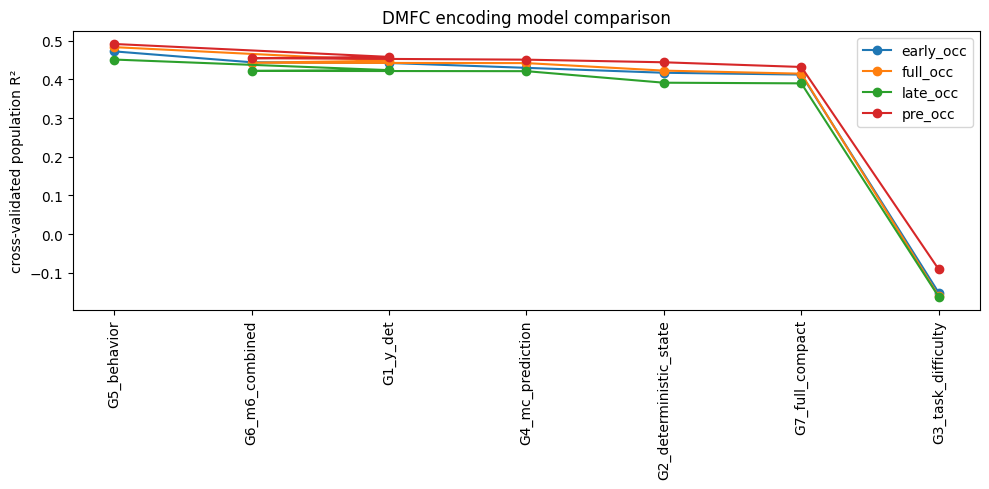

In [60]:
# some plots

plt.figure(figsize=(10, 5))

for win in encoding_summary["window"].unique():
    sub = encoding_summary[encoding_summary["window"] == win]
    plt.plot(
        sub["feature_group"],
        sub["population_r2"],
        marker="o",
        label=win,
    )

plt.xticks(rotation=90)
plt.ylabel("cross-validated population R²")
plt.title("DMFC encoding model comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
nested_groups = {
    "base_y_det": [
        "y_det",
    ],
    
    "base_plus_mc_mean": [
        "y_det",
        "mc_mean_M6",
    ],
    
    "base_plus_task": [
        "y_det",
        "abs_vy_occ",
        "n_steps",
    ],
    
    "base_plus_behavior": [
        "y_det",
        "y_paddle",
    ],
    
    "base_plus_all_compact": [
        "y_det",
        "mc_mean_M6",
        "abs_vy_occ",
        "n_steps",
        "y_paddle",
    ],
}

nested_groups = {
    name: [f for f in feats if f in analysis_df.columns]
    for name, feats in nested_groups.items()
}

In [62]:
nested_rows = []
nested_fold_rows = []

for win in analysis_df["window"].unique():
    for group_name, feats in nested_groups.items():
        cv_df, pop_r2 = evaluate_encoding_for_window(
            df=analysis_df,
            window=win,
            features=feats,
            unit_cols=unit_cols,
            n_splits=5,
            seed=42,
            alpha=1.0,
            min_unit_finite=0.2,
        )
        
        nested_rows.append({
            "window": win,
            "model": group_name,
            "features": ",".join(feats),
            "population_r2": pop_r2,
            "mean_fold_r2": cv_df["fold_population_r2"].mean(),
            "sem_fold_r2": cv_df["fold_population_r2"].std(ddof=1) / np.sqrt(len(cv_df)),
            "n_features": len(feats),
            "n_units": cv_df["n_units"].iloc[0],
        })
        
        cv_df["model"] = group_name
        cv_df["features"] = ",".join(feats)
        nested_fold_rows.append(cv_df)

nested_summary = pd.DataFrame(nested_rows)
nested_folds = pd.concat(nested_fold_rows, ignore_index=True)

display(
    nested_summary.sort_values(["window", "population_r2"], ascending=[True, False])
)

c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_im

,window,model,features,population_r2,mean_fold_r2,sem_fold_r2,n_features,n_units
8,early_occ,base_plus_behavior,"y_det,y_paddle",0.467186,0.467593,0.029631,2,32
9,early_occ,base_plus_all_compact,"y_det,mc_mean_M6,abs_vy_occ,n_steps,y_paddle",0.465105,0.466451,0.027152,5,32
6,early_occ,base_plus_mc_mean,"y_det,mc_mean_M6",0.444923,0.446954,0.037732,2,32
5,early_occ,base_y_det,y_det,0.442656,0.444647,0.037436,1,32
7,early_occ,base_plus_task,"y_det,abs_vy_occ,n_steps",0.442049,0.444578,0.034803,3,32
18,full_occ,base_plus_behavior,"y_det,y_paddle",0.480846,0.473993,0.030456,2,33
19,full_occ,base_plus_all_compact,"y_det,mc_mean_M6,abs_vy_occ,n_steps,y_paddle",0.472481,0.465506,0.029612,5,33
16,full_occ,base_plus_mc_mean,"y_det,mc_mean_M6",0.451558,0.444327,0.038058,2,33
15,full_occ,base_y_det,y_det,0.448578,0.441401,0.037935,1,33
17,full_occ,base_plus_task,"y_det,abs_vy_occ,n_steps",0.439149,0.431451,0.036786,3,33


# delta $R^2$

In [63]:
delta_rows = []

for win in nested_summary["window"].unique():
    sub = nested_summary[nested_summary["window"] == win].set_index("model")
    
    base_r2 = sub.loc["base_y_det", "population_r2"]
    
    for model_name in sub.index:
        if model_name == "base_y_det":
            continue
        
        delta_rows.append({
            "window": win,
            "model": model_name,
            "base_r2": base_r2,
            "model_r2": sub.loc[model_name, "population_r2"],
            "delta_r2_over_y_det": sub.loc[model_name, "population_r2"] - base_r2,
        })

delta_r2_df = pd.DataFrame(delta_rows).sort_values(
    ["window", "delta_r2_over_y_det"],
    ascending=[True, False],
)

display(delta_r2_df)

,window,model,base_r2,model_r2,delta_r2_over_y_det
6,early_occ,base_plus_behavior,0.442656,0.467186,0.024530
7,early_occ,base_plus_all_compact,0.442656,0.465105,0.022449
4,early_occ,base_plus_mc_mean,0.442656,0.444923,0.002267
5,early_occ,base_plus_task,0.442656,0.442049,-0.000607
14,full_occ,base_plus_behavior,0.448578,0.480846,0.032268
15,full_occ,base_plus_all_compact,0.448578,0.472481,0.023903
12,full_occ,base_plus_mc_mean,0.448578,0.451558,0.002981
13,full_occ,base_plus_task,0.448578,0.439149,-0.009428
10,late_occ,base_plus_behavior,0.424147,0.449520,0.025373
11,late_occ,base_plus_all_compact,0.424147,0.443655,0.019508


In [64]:
ENC_SUMMARY_PATH = PROCESSED_DIR / "dmfc_encoding_summary_mahler.csv"
ENC_FOLDS_PATH = PROCESSED_DIR / "dmfc_encoding_folds_mahler.csv"
NESTED_SUMMARY_PATH = PROCESSED_DIR / "dmfc_nested_encoding_summary_mahler.csv"
DELTA_R2_PATH = PROCESSED_DIR / "dmfc_nested_delta_r2_mahler.csv"

encoding_summary.to_csv(ENC_SUMMARY_PATH, index=False)
encoding_folds.to_csv(ENC_FOLDS_PATH, index=False)
nested_summary.to_csv(NESTED_SUMMARY_PATH, index=False)
delta_r2_df.to_csv(DELTA_R2_PATH, index=False)

print("Saved:", ENC_SUMMARY_PATH)
print("Saved:", ENC_FOLDS_PATH)
print("Saved:", NESTED_SUMMARY_PATH)
print("Saved:", DELTA_R2_PATH)

Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_encoding_summary_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_encoding_folds_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_nested_encoding_summary_mahler.csv
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_nested_delta_r2_mahler.csv


y_paddle은 y_det 이상으로 DMFC activity 를 설명함.
mc_mean_M6 는 거의 추가 설명력이 없음
task difficulty 는 추가 설명령이 없고 오히려 성능을 떨어뜨림

DMFC 는 MC-derived mean/uncertainty 보다 animal response variable을 더 잘 반영함.

In [65]:
# Use global linear fit for diagnostic residual.
# Later, this can be made cross-validated, but this is fine for preliminary analysis.

valid = np.isfinite(analysis_df["y_det"]) & np.isfinite(analysis_df["y_paddle"])

coef = np.polyfit(
    analysis_df.loc[valid, "y_det"],
    analysis_df.loc[valid, "y_paddle"],
    deg=1,
)

gain_global = coef[0]
intercept_global = coef[1]

analysis_df["y_paddle_pred_from_y_det"] = (
    gain_global * analysis_df["y_det"] + intercept_global
)

analysis_df["paddle_residual_from_y_det"] = (
    analysis_df["y_paddle"] - analysis_df["y_paddle_pred_from_y_det"]
)

print("global gain:", gain_global)
print("global intercept:", intercept_global)

display(
    analysis_df[[
        "condition_i",
        "window",
        "y_det",
        "y_paddle",
        "y_paddle_pred_from_y_det",
        "paddle_residual_from_y_det",
    ]].head()
)

global gain: 0.8736645456633183
global intercept: -0.21198693774334967


C:\Users\ksbong\AppData\Local\Temp\ipykernel_40432\2732654992.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  analysis_df["y_paddle_pred_from_y_det"] = (
C:\Users\ksbong\AppData\Local\Temp\ipykernel_40432\2732654992.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  analysis_df["paddle_residual_from_y_det"] = (


,condition_i,window,y_det,y_paddle,y_paddle_pred_from_y_det,paddle_residual_from_y_det
0,0,pre_occ,-0.271351,-0.688933,-0.449056,-0.239876
1,0,early_occ,-0.271351,-0.688933,-0.449056,-0.239876
2,0,late_occ,-0.271351,-0.688933,-0.449056,-0.239876
3,0,full_occ,-0.271351,-0.688933,-0.449056,-0.239876
4,1,pre_occ,-5.085588,-3.723874,-4.655085,0.931211


In [66]:
# residual nested groups

residual_groups = {
    "base_y_det": [
        "y_det",
    ],
    
    "base_plus_paddle": [
        "y_det",
        "y_paddle",
    ],
    
    "base_plus_paddle_residual": [
        "y_det",
        "paddle_residual_from_y_det",
    ],
    
    "residual_only": [
        "paddle_residual_from_y_det",
    ],
}

In [67]:
residual_rows = []
residual_fold_rows = []

for win in analysis_df["window"].unique():
    for group_name, feats in residual_groups.items():
        cv_df, pop_r2 = evaluate_encoding_for_window(
            df=analysis_df,
            window=win,
            features=feats,
            unit_cols=unit_cols,
            n_splits=5,
            seed=42,
            alpha=1.0,
            min_unit_finite=0.2,
        )
        
        residual_rows.append({
            "window": win,
            "model": group_name,
            "features": ",".join(feats),
            "population_r2": pop_r2,
            "mean_fold_r2": cv_df["fold_population_r2"].mean(),
            "sem_fold_r2": cv_df["fold_population_r2"].std(ddof=1) / np.sqrt(len(cv_df)),
            "n_features": len(feats),
            "n_units": cv_df["n_units"].iloc[0],
        })
        
        cv_df["model"] = group_name
        cv_df["features"] = ",".join(feats)
        residual_fold_rows.append(cv_df)

residual_summary = pd.DataFrame(residual_rows)
residual_folds = pd.concat(residual_fold_rows, ignore_index=True)

display(
    residual_summary.sort_values(
        ["window", "population_r2"],
        ascending=[True, False],
    )
)

c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\.venv\Lib\site-packages\numpy\lib\_nanfunctions_im

,window,model,features,population_r2,mean_fold_r2,sem_fold_r2,n_features,n_units
5,early_occ,base_plus_paddle,"y_det,y_paddle",0.467186,0.467593,0.029631,2,32
6,early_occ,base_plus_paddle_residual,"y_det,paddle_residual_from_y_det",0.463417,0.463758,0.029733,2,32
4,early_occ,base_y_det,y_det,0.442656,0.444647,0.037436,1,32
7,early_occ,residual_only,paddle_residual_from_y_det,0.008290,0.007768,0.021589,1,32
13,full_occ,base_plus_paddle,"y_det,y_paddle",0.480846,0.473993,0.030456,2,33
14,full_occ,base_plus_paddle_residual,"y_det,paddle_residual_from_y_det",0.477865,0.470875,0.030636,2,33
12,full_occ,base_y_det,y_det,0.448578,0.441401,0.037935,1,33
15,full_occ,residual_only,paddle_residual_from_y_det,0.021569,0.021673,0.025927,1,33
9,late_occ,base_plus_paddle,"y_det,y_paddle",0.449520,0.441797,0.031801,2,33
10,late_occ,base_plus_paddle_residual,"y_det,paddle_residual_from_y_det",0.446009,0.438100,0.032183,2,33


# Residual delta $R^2$

In [68]:
residual_delta_rows = []

for win in residual_summary["window"].unique():
    sub = residual_summary[residual_summary["window"] == win].set_index("model")
    
    base_r2 = sub.loc["base_y_det", "population_r2"]
    
    for model_name in sub.index:
        if model_name == "base_y_det":
            continue
        
        residual_delta_rows.append({
            "window": win,
            "model": model_name,
            "base_r2": base_r2,
            "model_r2": sub.loc[model_name, "population_r2"],
            "delta_r2_over_y_det": sub.loc[model_name, "population_r2"] - base_r2,
        })

residual_delta_df = pd.DataFrame(residual_delta_rows).sort_values(
    ["window", "delta_r2_over_y_det"],
    ascending=[True, False],
)

display(residual_delta_df)

,window,model,base_r2,model_r2,delta_r2_over_y_det
3,early_occ,base_plus_paddle,0.442656,0.467186,0.024530
4,early_occ,base_plus_paddle_residual,0.442656,0.463417,0.020761
5,early_occ,residual_only,0.442656,0.008290,-0.434366
9,full_occ,base_plus_paddle,0.448578,0.480846,0.032268
10,full_occ,base_plus_paddle_residual,0.448578,0.477865,0.029287
11,full_occ,residual_only,0.448578,0.021569,-0.427009
6,late_occ,base_plus_paddle,0.424147,0.449520,0.025373
7,late_occ,base_plus_paddle_residual,0.424147,0.446009,0.021862
8,late_occ,residual_only,0.424147,0.012475,-0.411672
0,pre_occ,base_plus_paddle,0.458412,0.488152,0.029740


1. y_det만으로 DMFC activity가 꽤 잘 설명됨.
   → DMFC activity는 physical target / predicted final position과 강하게 관련 있음.

2. y_det + y_paddle residual이 y_det alone보다 더 잘 설명함.
   → DMFC activity에는 physical target으로 설명되지 않는 behavioral-endpoint-related variance가 있음.

3. residual only는 거의 설명력이 없음.
   → behavioral deviation 단독이 주된 neural axis는 아님.
   → 기본 축은 여전히 physical/action target이고, residual은 그 위에 얹힌 작은 modulation임.